In [1]:
#Jupyter Notebook for Experiment 1 in Physics Lab III - Coupled Pendula.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

plt.rcParams['figure.dpi'] = 120
plt.rcParams.update({'font.size':12, 'font.family':'serif'}) #Setting fonts
plt.rcParams['text.usetex'] = False

import string #For figure labels

# Part A - Calculating Spring Constants

## Spring 1 

In [2]:
#Method 1 - Using extension and force
masses = np.array([15.1, 17.2, 19.2, 21.8, 25.2, 27, 29.3])/1000
lengths = np.array([15.2, 17, 19.2, 22, 26, 28.3, 30.6])/100

mass = (masses - masses[0] + (masses[0]/2)) * 9.81

extensions = []
for i in lengths:
    val = i - lengths[0]
    extensions.append(val)

extensions = np.array(extensions)
print(mass)

[0.0740655 0.0946665 0.1142865 0.1397925 0.1731465 0.1908045 0.2133675]


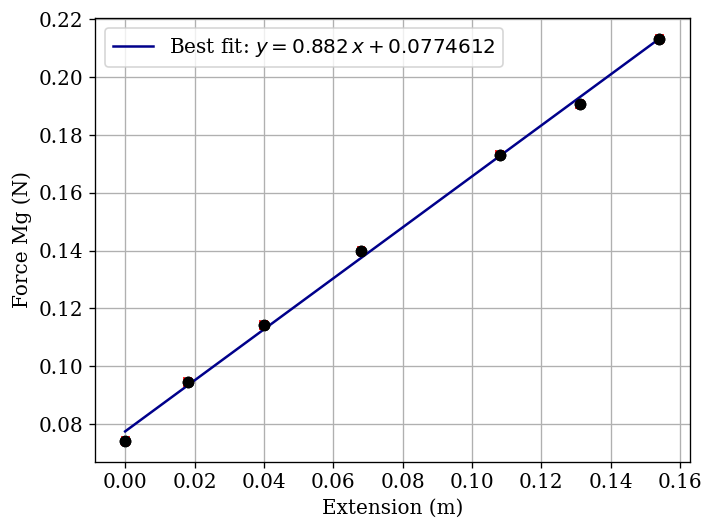

In [3]:
delta_x = 0.001   # 1 mm in meters
delta_m = 0.0001  # 0.1 g in kg

plt.scatter(extensions, mass, c='k')
plt.xlabel("Extension (m)")
plt.ylabel(r"Force Mg (N)")

plt.errorbar(
    extensions, mass, 
    xerr=delta_x, yerr=delta_m, 
    fmt='o', c='k', ecolor='red', capsize=3
)

m,c = np.polyfit(extensions, mass, deg=1)
y_fit = m*extensions + c
plt.plot(
    extensions, y_fit, c="darkblue",
    label=fr"Best fit: $y = {m:.3f}\, x + {c:.7f}$"
)
plt.legend()
plt.grid()
# plt.savefig("S1_extensionplot.jpg")

In [4]:
print("Spring constant from extension is",m)

Spring constant from extension is 0.8822757482913032


In [5]:
#Method 2 - Using Time Period and Frequency
timelist = [[6.03,6.1,6], [6.72,6.69,6.87],[7.56,7.47,7.53],[8.5,8.5,8.5],[9.06,9.06,9.03],[9.46,9.44,9.64]]
avgtimes = []
for i in timelist:
    val = np.mean(i)
    avgtimes.append(val)

avgtimes = np.array(avgtimes)/10

mass_eff = (masses - masses[0] + (masses[0]/3))
mass_eff = mass_eff[1:]
timesqr = avgtimes**2

print(avgtimes)
print(mass_eff)

[0.60433333 0.676      0.752      0.85       0.905      0.95133333]
[0.00713333 0.00913333 0.01173333 0.01513333 0.01693333 0.01923333]


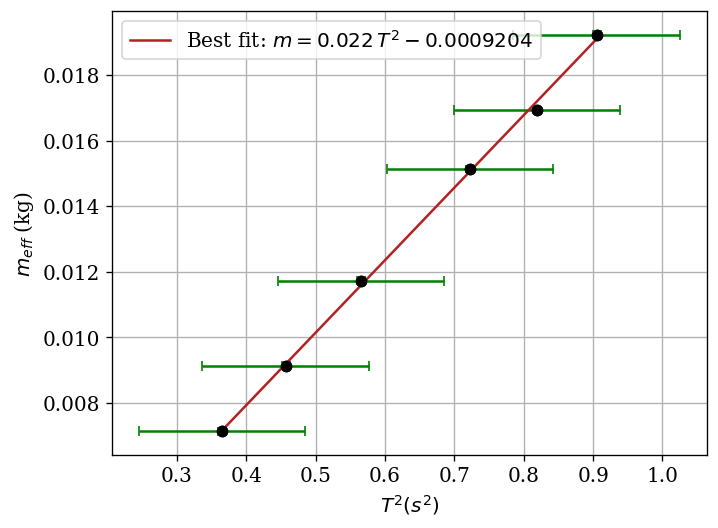

In [6]:
delta_T = 0.12 
delta_m = 0.0001  

plt.scatter(timesqr, mass_eff,c='k')
plt.xlabel(r"$T^2 (s^2)$")
plt.ylabel(r"$m_{eff}$ (kg)")

plt.errorbar(
    timesqr, mass_eff, 
    xerr=delta_T, yerr=delta_m, 
    fmt='o', c='k', ecolor='green', capsize=3
)

slope,c = np.polyfit(timesqr, mass_eff, deg=1)
y_fits = slope*timesqr + c
plt.plot(
    timesqr, y_fits, c="firebrick",
    label=fr"Best fit: $m = {slope:.3f}\,T^2 {c:.7f}$"
)
plt.legend()
plt.grid()
# plt.savefig("S1_timeperiod.jpg")

In [7]:
k = 4 * np.pi**2 * slope
print("Spring Constant from Time period is",k)

Spring Constant from Time period is 0.8733517914791672


## Spring 2

In [8]:
#Method 1 - Using extension and force
masses2 = np.array([20.4,30.4,35,40.6,45.1,50.8,60.6])/1000
lengths2 = np.array([13, 16.7, 18.6, 20.8, 22.5, 24.8, 28.5])/100

mass2 = (masses2 - masses2[0] + (masses2[0]/2)) * 9.81

extensions2 = []
for i in lengths2:
    val = i - lengths2[0]
    extensions2.append(val)

extensions2 = np.array(extensions2)
print(mass2)

[0.100062 0.198162 0.243288 0.298224 0.342369 0.398286 0.494424]


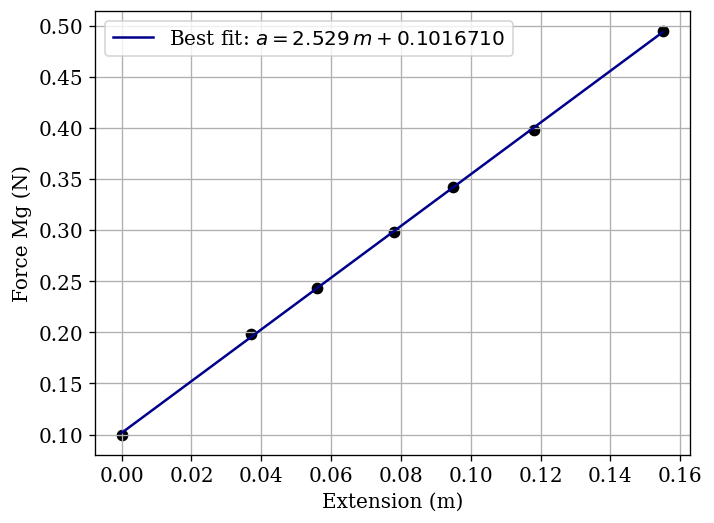

In [9]:
plt.scatter(extensions2, mass2, c='k')
plt.xlabel("Extension (m)")
plt.ylabel(r"Force Mg (N)")

m2,c2 = np.polyfit(extensions2, mass2, deg=1)
y_fit2 = m2*extensions2 + c2
plt.plot(
    extensions2, y_fit2, c="darkblue",
    label=fr"Best fit: $a = {m2:.3f}\,m + {c2:.7f}$"
)
plt.legend()
plt.grid()

In [10]:
print("Spring constant 2 from extension is",m2)

Spring constant 2 from extension is 2.5289764632627643


In [11]:
#Method 2 - Using Time Period and Frequency
timelist2 = [[5.37,5.31,5.4],[5.87,6,5.97],[6.62,6.66,6.66],[7.15,7.31,7.28],[7.82,7.81,7.78],[8.81,8.78,8.82]]
avgtimes2 = []
for i in timelist2:
    val = np.mean(i)
    avgtimes2.append(val)

avgtimes2 = np.array(avgtimes2)/10

mass_eff2 = (masses2 - masses2[0] + (masses2[0]/3))
mass_eff2 = mass_eff2[1:]
timesqr2 = avgtimes2**2
print(avgtimes2)
print(mass_eff2)

[0.536      0.59466667 0.66466667 0.72466667 0.78033333 0.88033333]
[0.0168 0.0214 0.027  0.0315 0.0372 0.047 ]


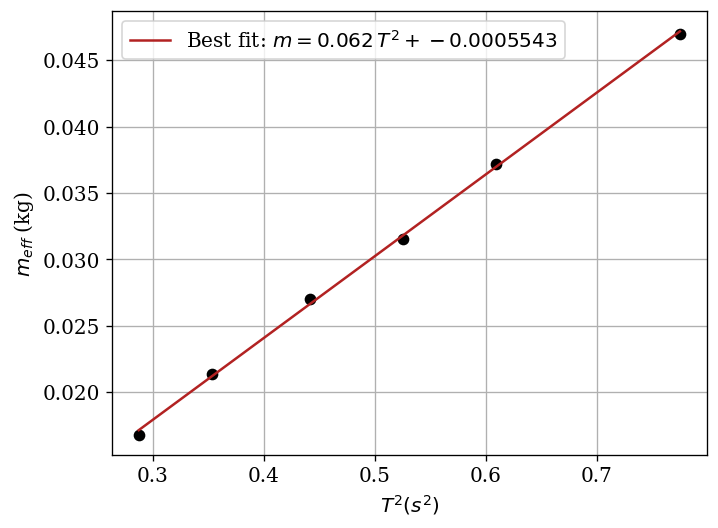

In [12]:
plt.scatter(timesqr2, mass_eff2,c='k')
plt.xlabel(r"$T^2 (s^2)$")
plt.ylabel(r"$m_{eff}$ (kg)")

slope2,c3 = np.polyfit(timesqr2, mass_eff2, deg=1)
y_fits2 = slope2*timesqr2 + c3
plt.plot(
    timesqr2, y_fits2, c="firebrick",
    label=fr"Best fit: $m = {slope2:.3f}\,T^2 + {c3:.7f}$"
)
plt.legend()
plt.grid()

In [13]:
k2 = 4 * np.pi**2 * slope2
print("Spring Constant 2 from Time period is",k2)

Spring Constant 2 from Time period is 2.4309950890057435


## Spring 3

In [14]:
#Method 1 - Using extension and force
masses3 = np.array([21.1,26.7,31.1,36.8,41.4,46.9,51.4])/1000
lengths3 = np.array([12.6,14.5,16.5,19.1,21.4,24.1,26.5])/100

mass3 = (masses3 - masses3[0] + (masses3[0]/2)) * 9.81

extensions3 = []
for i in lengths3:
    val = i - lengths3[0]
    extensions3.append(val)

extensions3 = np.array(extensions3)
print(mass3)

[0.1034955 0.1584315 0.2015955 0.2575125 0.3026385 0.3565935 0.4007385]


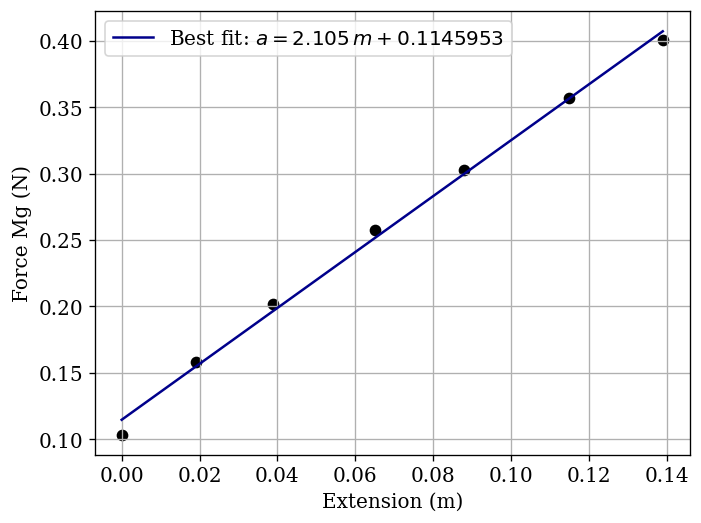

In [15]:
plt.scatter(extensions3, mass3, c='k')
plt.xlabel("Extension (m)")
plt.ylabel(r"Force Mg (N)")

m3,c5 = np.polyfit(extensions3, mass3, deg=1)
y_fit3 = m3*extensions3 + c5
plt.plot(
    extensions3, y_fit3, c="darkblue",
    label=fr"Best fit: $a = {m3:.3f}\,m + {c5:.7f}$"
)
plt.legend()
plt.grid()

In [16]:
print("Spring constant 2 from extension is",m3)

Spring constant 2 from extension is 2.1050282347955855


In [17]:
#Method 2 - Using Time Period and Frequency
timelist3 = [[4.88,4.87,4.85],[5.87,5.82,5.75],[6.81,6.72,6.79],[7.32,7.34,7.37],[8.09,8.12,8.06],[8.56,8.60,8.66]]
avgtimes3 = []
for i in timelist3:
    val = np.mean(i)
    avgtimes3.append(val)

avgtimes3 = np.array(avgtimes3)/10

mass_eff3 = (masses3 - masses3[0] + (masses3[0]/3))
mass_eff3 = mass_eff3[1:]
timesqr3 = avgtimes3**2
print(avgtimes3)
print(mass_eff3)

[0.48666667 0.58133333 0.67733333 0.73433333 0.809      0.86066667]
[0.01263333 0.01703333 0.02273333 0.02733333 0.03283333 0.03733333]


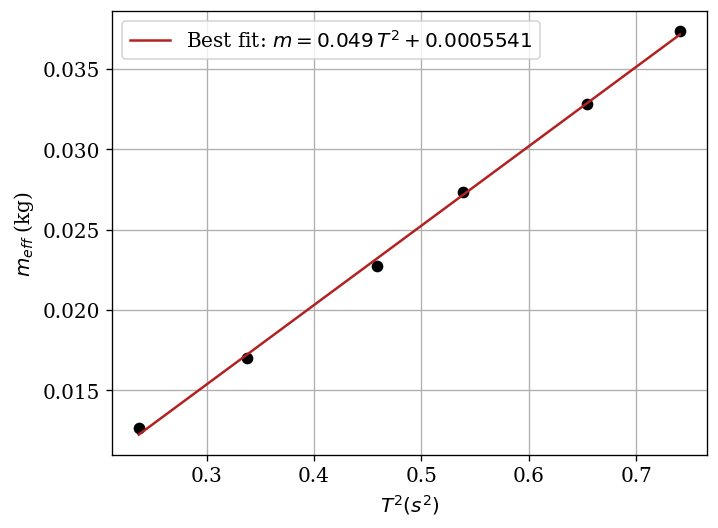

In [18]:
plt.scatter(timesqr3, mass_eff3,c='k')
plt.xlabel(r"$T^2 (s^2)$")
plt.ylabel(r"$m_{eff}$ (kg)")

slope3,c6 = np.polyfit(timesqr3, mass_eff3, deg=1)
y_fits3 = slope3*timesqr3 + c6
plt.plot(
    timesqr3, y_fits3, c="firebrick",
    label=fr"Best fit: $m = {slope3:.3f}\,T^2 + {c6:.7f}$"
)
plt.legend()
plt.grid()

In [19]:
k3 = 4 * np.pi**2 * slope3
print("Spring Constant 2 from Time period is",k3)

Spring Constant 2 from Time period is 1.9496183119892239


# Part B - Normal Modes and Beats

## Spring 1

In [20]:
from numpy.fft import fft,fftfreq
from scipy.signal import find_peaks

def getfft(t1,x1,t2,x2, prominence=20, delta=[0.1,1000]):
    fft_vals = fft(x1)
    freqs = fftfreq((len(fft_vals)), t1[1] - t1[0])
    
    fft_vals2 = fft(x2)
    freqs2 = fftfreq((len(fft_vals2)), t2[1] - t2[0])
    plt.plot(freqs, np.abs(fft_vals),c='#110EB0', label="Signal 1")
    plt.plot(freqs2, np.abs(fft_vals2),c='#E3541B', label="Signal 2")
    plt.legend()
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Intensity")
    # plt.title("Fast Fourier Transform")
    # plt.savefig("S2_random_fft.jpg")
    plt.show()
    
    plt.plot(freqs, np.abs(fft_vals),c='#110EB0', label="Signal 1")
    plt.plot(freqs2, np.abs(fft_vals2),c='#E3541B', label="Signal 2")
    peaks1,_ = find_peaks(np.abs(fft_vals), prominence = prominence)
    peaks2,_ = find_peaks(np.abs(fft_vals2), prominence = prominence)
    print(peaks1)
    print(len(peaks1))
    # print(len(peaks1))
    plt.xlim(abs(freqs[peaks1[1]])-delta[0],abs(freqs2[peaks2[1]])+delta[0])
    plt.ylim(0,abs(fft_vals[peaks1[1]])+delta[1])
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Intensity")
    # plt.title("FFT Peak")
    plt.legend()
    # plt.savefig("S2_random_peak.jpg")
    return freqs[peaks1],freqs2[peaks2]

def plotwaves(file1,file2,prominence=100,delta=[0.1,1000]):
    t1 = []
    x1 = []
    for i in file1:
        t1.append(i[0])
        x1.append(i[1])
    x1=(x1-min(x1)) / (max(x1)-min(x1))
    x1=np.array(x1)
    t2 = []
    x2 = []
    for i in file2:
        t2.append(i[0])
        x2.append(i[1])
    
    x2=(x2-min(x2))/(max(x2)-min(x2))
    x2=np.array(x2)
    
    plt.plot(t1,x1,c='#E3541B',label="Mass 1")
    plt.plot(t2,x2,c='#110EB0',label="Mass 2")
    plt.xlabel("Time (s)")
    plt.ylabel("x normalised")
    plt.legend()
    # plt.title("Signal Patterns")
    plt.savefig("S2_random.jpg")
    plt.show()
    p1,p2 = getfft(t1,x1,t2,x2,delta=delta)
    print("First peak is ",p1)
    print("Second peak is ",p2)


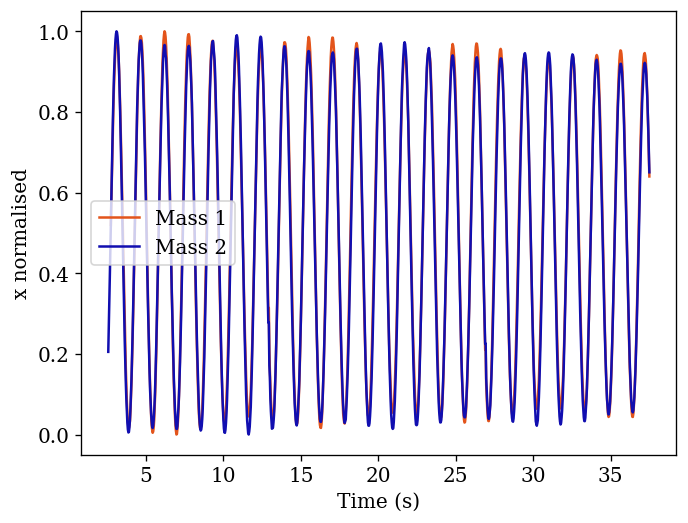

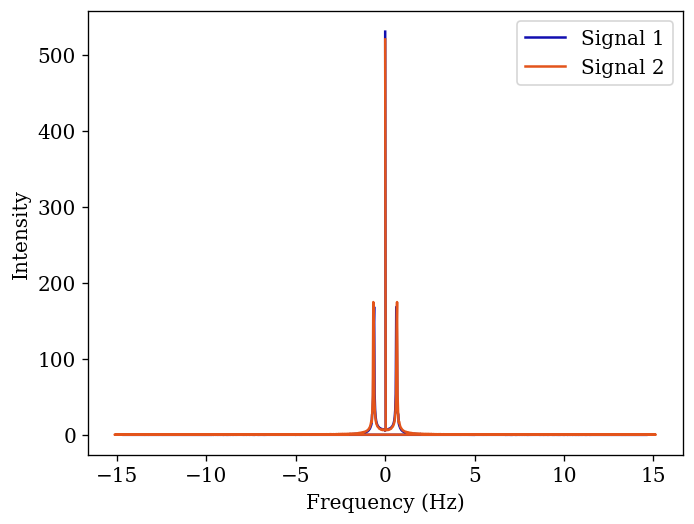

[  22 1022]
2
First peak is  [ 0.61978815 -0.61978815]
Second peak is  [ 0.66441344 -0.66441344]


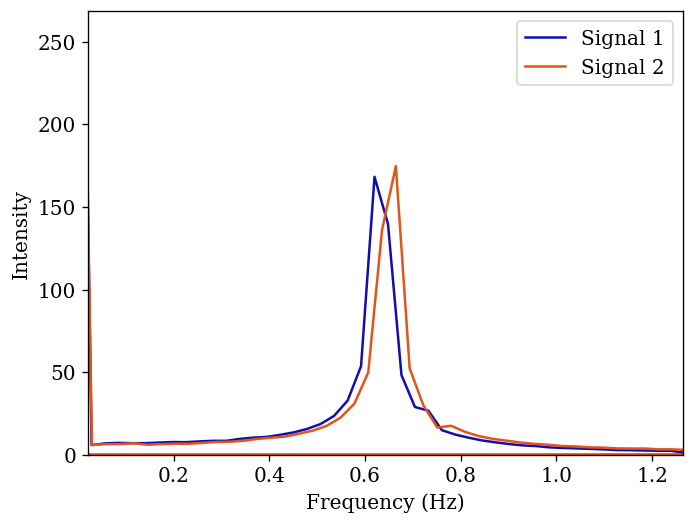

In [21]:
S1_inphaseA = np.loadtxt("../Coupled_Pendulum/S1_inphase_mA.txt", delimiter=',', skiprows=2)
S1_inphaseB = np.loadtxt("../Coupled_Pendulum/S1_inphase_mB.txt", delimiter=',', skiprows=2)

plotwaves(S1_inphaseA, S1_inphaseB,delta=[0.6,100])

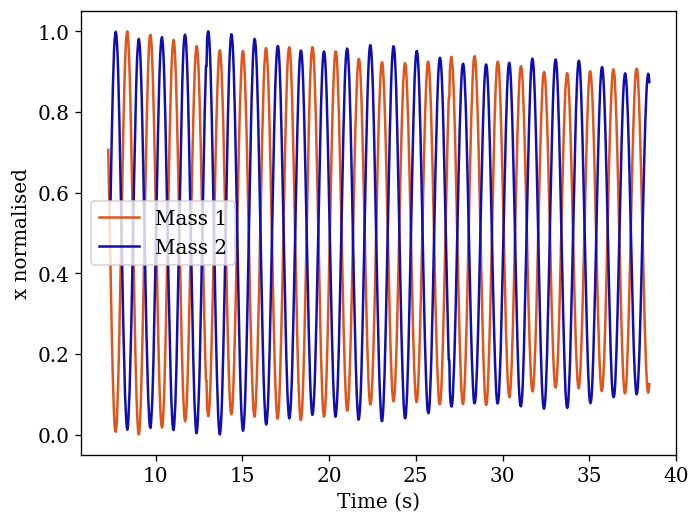

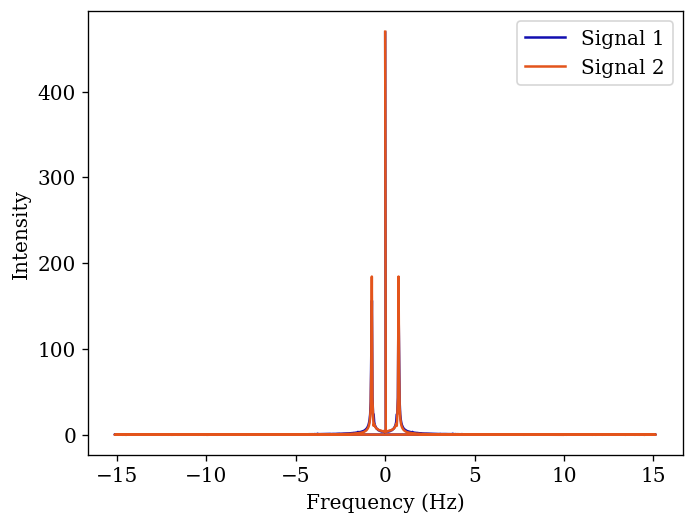

[ 23 914]
2
First peak is  [ 0.74383105 -0.74383105]
Second peak is  [ 0.74702004 -0.74702004]


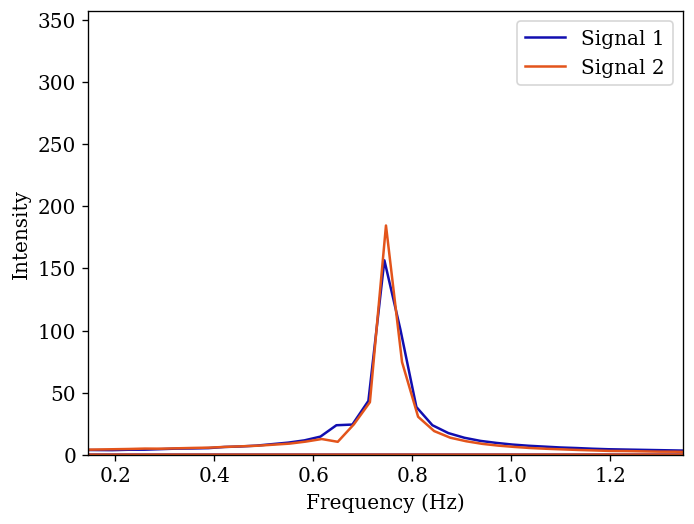

In [22]:
S1_outphaseA = np.loadtxt("../Coupled_Pendulum/S1_outphase_mA.txt", delimiter=',', skiprows=2)
S1_outphaseB = np.loadtxt("../Coupled_Pendulum/S1_outphase_mB.txt", delimiter=',', skiprows=2)

plotwaves(S1_outphaseA, S1_outphaseB,delta=[0.6,200])

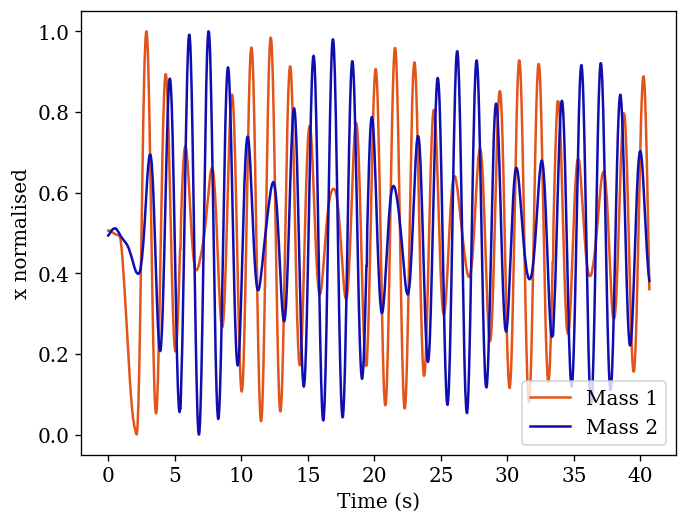

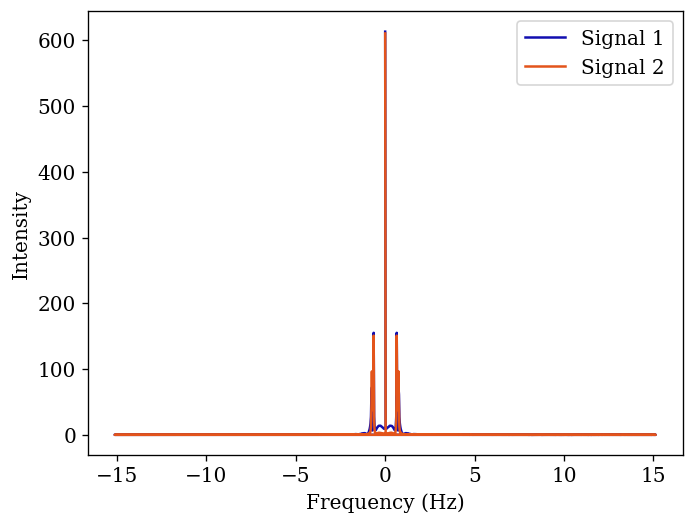

[  26   30 1191 1195]
4
First peak is  [ 0.64527337  0.7445462  -0.7445462  -0.64527337]
Second peak is  [ 0.64527337  0.7445462  -0.7445462  -0.64527337]


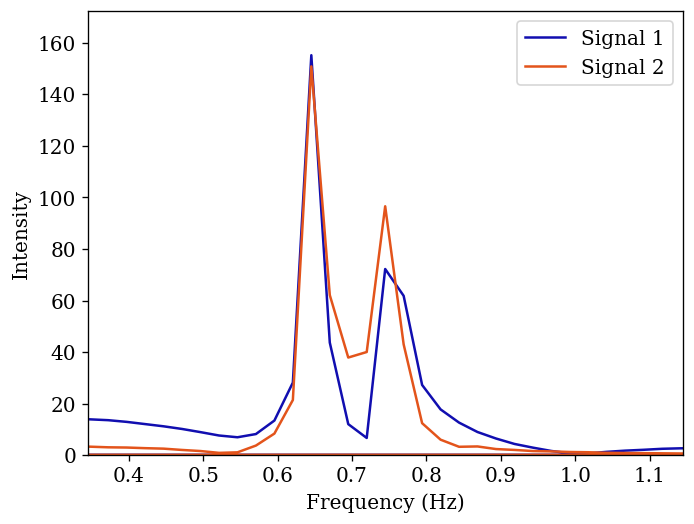

In [23]:
S1_beatsA = np.loadtxt("../Coupled_Pendulum/S1_beats_mA.txt", delimiter=',', skiprows=2)
S1_beatsB = np.loadtxt("../Coupled_Pendulum/S1_beats_mB.txt", delimiter=',', skiprows=2)

plotwaves(S1_beatsA, S1_beatsB,delta=[0.4,100])

## Spring 2

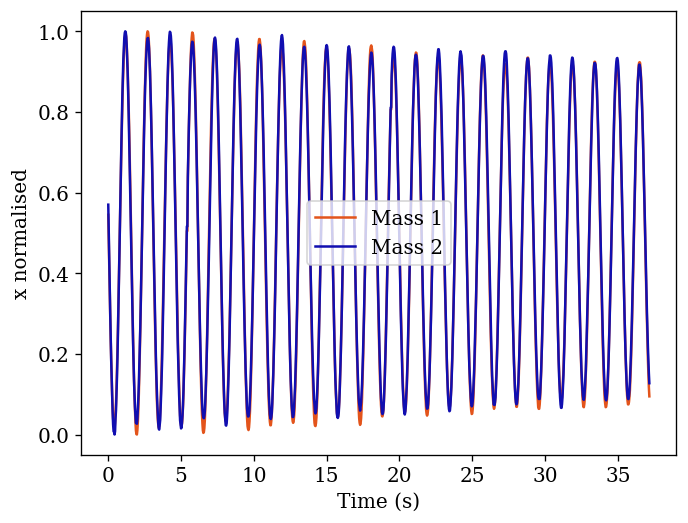

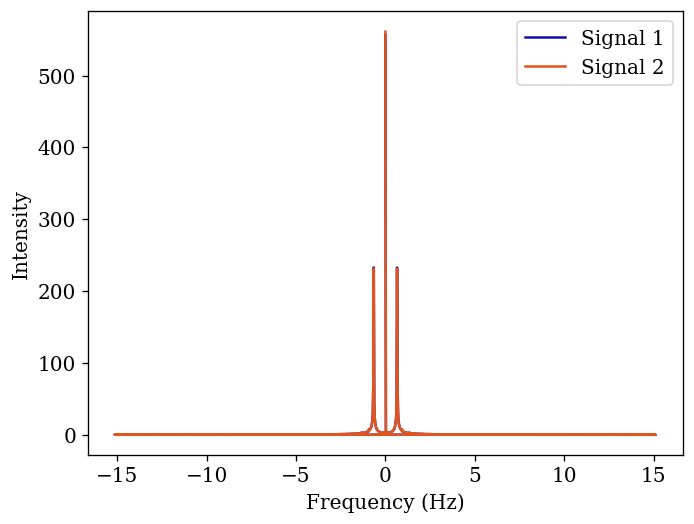

[  24 1092]
2
First peak is  [ 0.65167807 -0.65167807]
Second peak is  [ 0.65167807 -0.65167807]


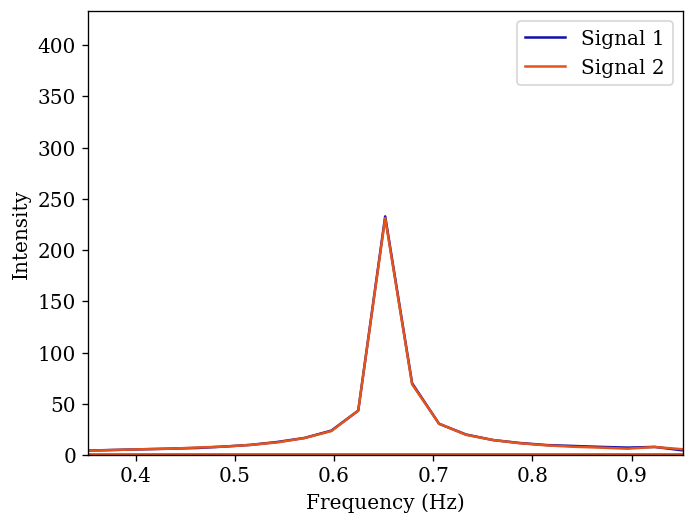

In [24]:
S2_inphaseA = np.loadtxt("../Coupled_Pendulum/S2_inphase_mA.txt", delimiter=',', skiprows=2)
S2_inphaseB = np.loadtxt("../Coupled_Pendulum/S2_inphase_mB.txt", delimiter=',', skiprows=2)

plotwaves(S2_inphaseA, S2_inphaseB,delta=[0.3,200])

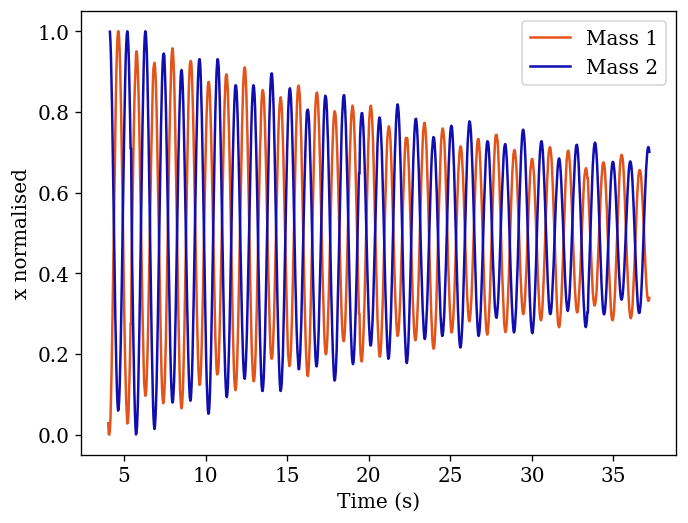

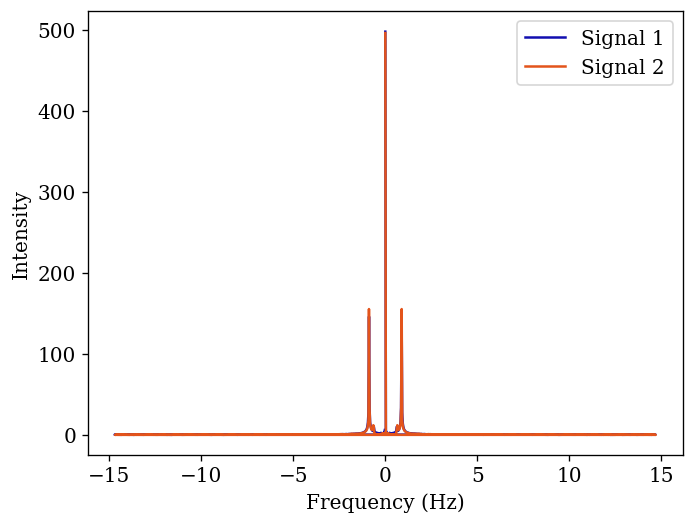

[ 30 966]
2
First peak is  [ 0.88589653 -0.88589653]
Second peak is  [ 0.88857295 -0.88857295]


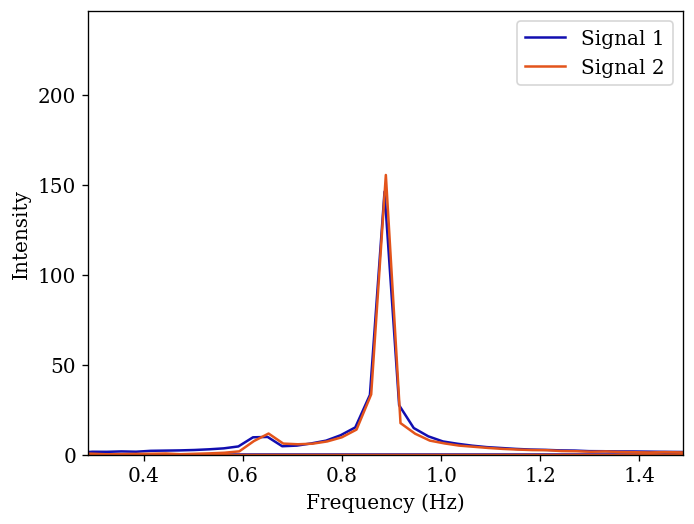

In [25]:
#Check again. 
S2_outphaseA = np.loadtxt("../Coupled_Pendulum/S2_outphase_mA.txt", delimiter=',', skiprows=2)
S2_outphaseB = np.loadtxt("../Coupled_Pendulum/S2_outphase_mB.txt", delimiter=',', skiprows=2)

plotwaves(S2_outphaseA, S2_outphaseB,delta=[0.6,100])

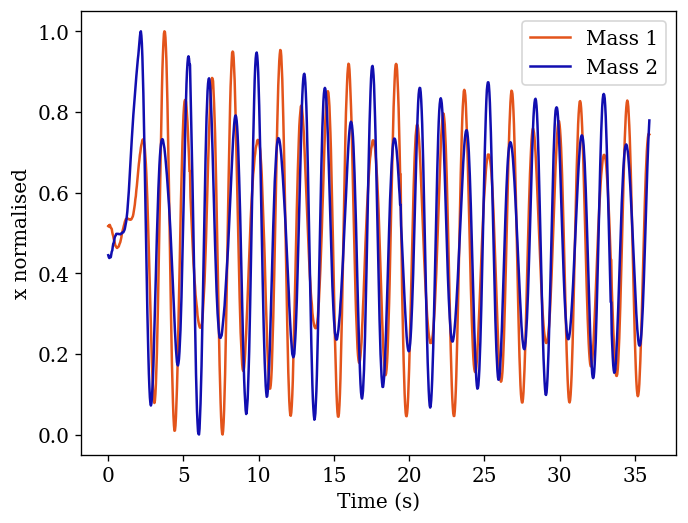

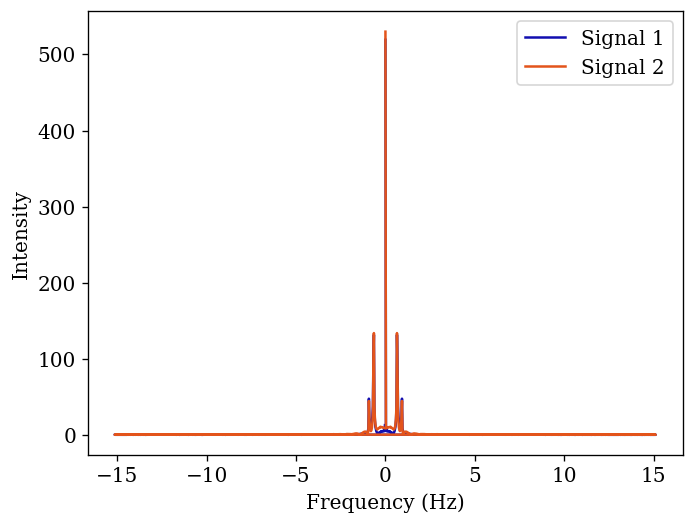

[  23   33 1047 1057]
4
First peak is  [ 0.64534231  0.92592593 -0.92592593 -0.64534231]
Second peak is  [ 0.64534231  0.92592593 -0.92592593 -0.64534231]


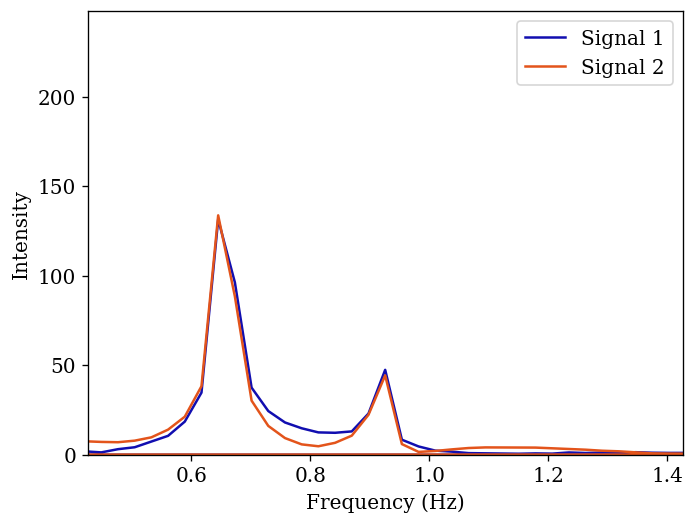

In [26]:
S2_beatsA = np.loadtxt("../Coupled_Pendulum/S2_beats_mA.txt", delimiter=',', skiprows=2)
S2_beatsB = np.loadtxt("../Coupled_Pendulum/S2_beats_mB.txt", delimiter=',', skiprows=2)

plotwaves(S2_beatsA, S2_beatsB,delta=[0.5,200])

## Spring 3

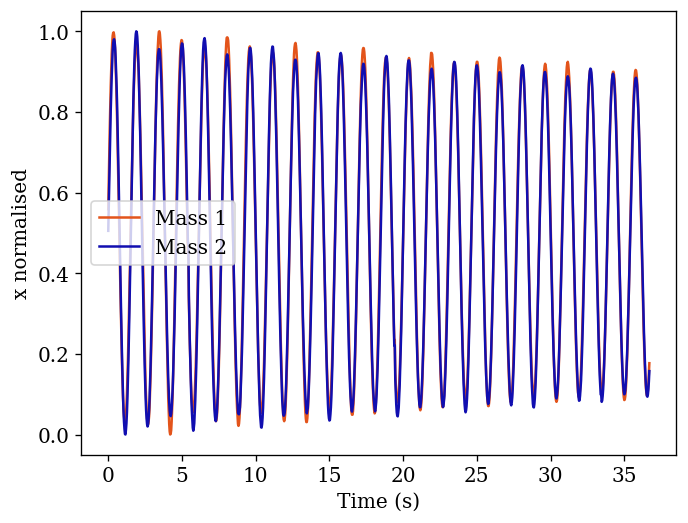

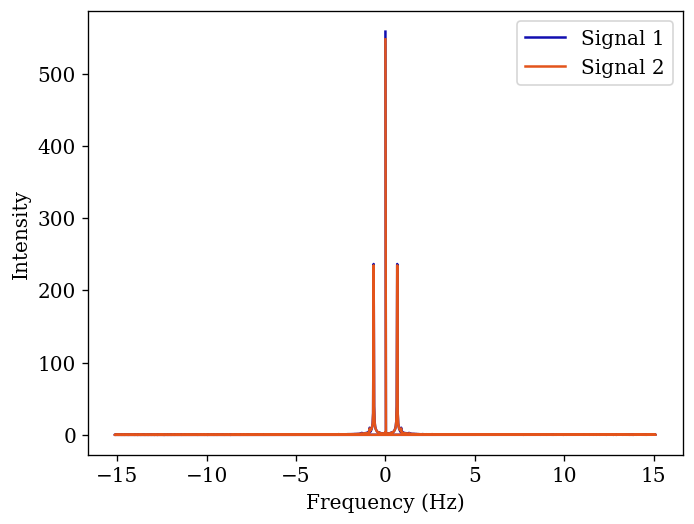

[  24 1078]
2
First peak is  [ 0.6599571 -0.6599571]
Second peak is  [ 0.6599571 -0.6599571]


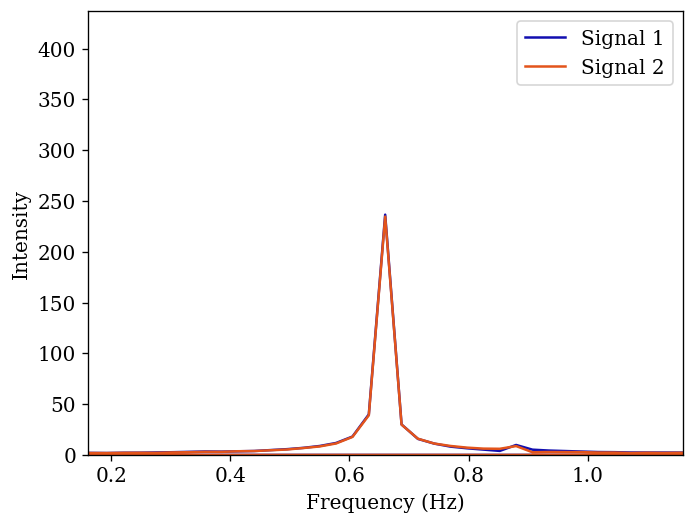

In [27]:
S3_inphaseA = np.loadtxt("../Coupled_Pendulum/S3_inphase_mA.txt", delimiter=',', skiprows=2)
S3_inphaseB = np.loadtxt("../Coupled_Pendulum/S3_inphase_mB.txt", delimiter=',', skiprows=2)

plotwaves(S3_inphaseA, S3_inphaseB,delta=[0.5,200])

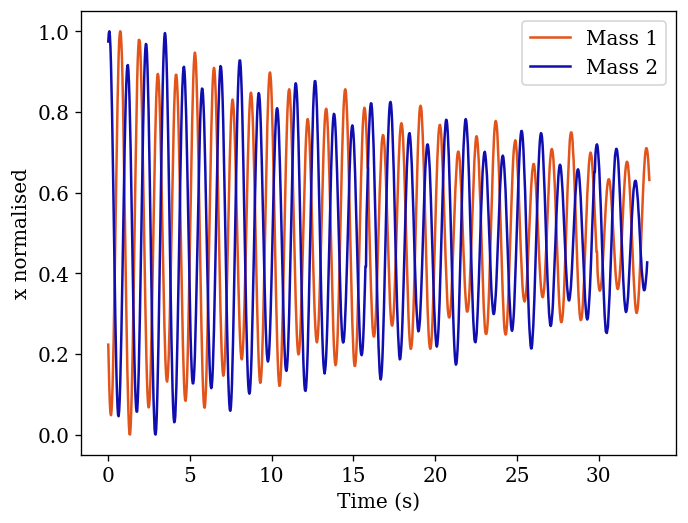

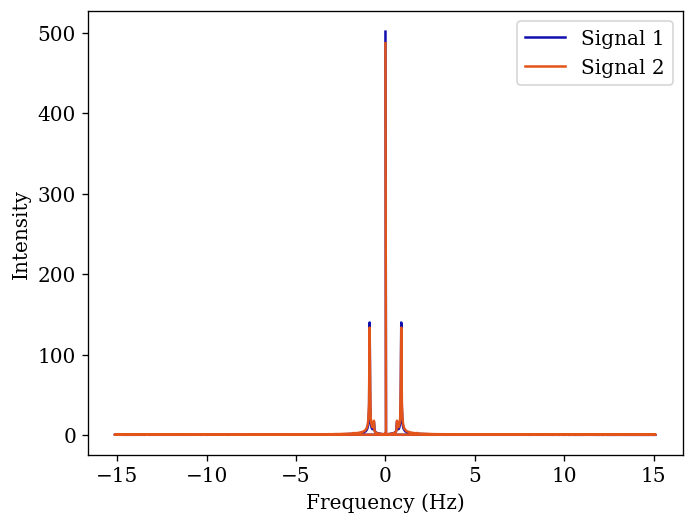

[ 29 965]
2
First peak is  [ 0.88409243 -0.88409243]
Second peak is  [ 0.88766452 -0.88766452]


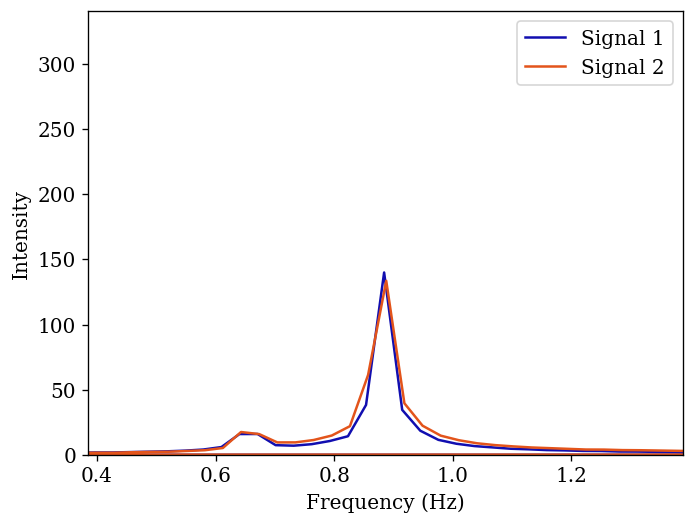

In [28]:
S3_outphaseA = np.loadtxt("../Coupled_Pendulum/S3_outphase2_mA.txt", delimiter=',', skiprows=2)
S3_outphaseB = np.loadtxt("../Coupled_Pendulum/S3_outphase_mB.txt", delimiter=',', skiprows=2)

plotwaves(S3_outphaseA, S3_outphaseB,delta=[0.5,200])

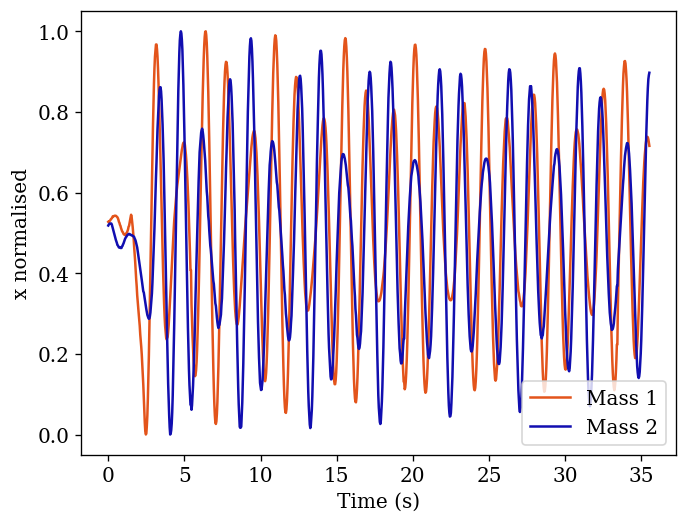

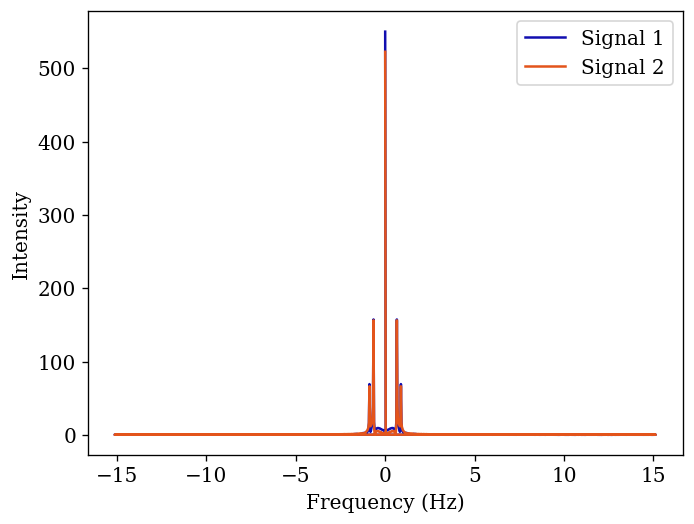

[  23   31 1036 1044]
4
First peak is  [ 0.65320496  0.88040669 -0.88040669 -0.65320496]
Second peak is  [ 0.65320496  0.88040669 -0.88040669 -0.65320496]


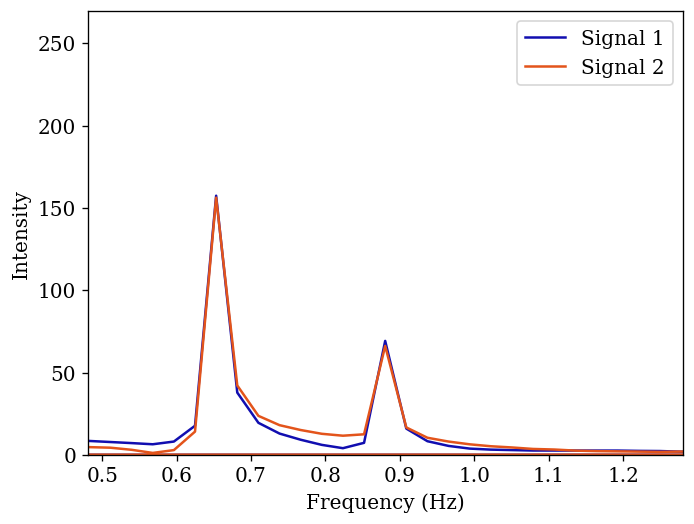

In [29]:
S3_beatsA = np.loadtxt("../Coupled_Pendulum/S3_beats_mA.txt", delimiter=',', skiprows=2)
S3_beatsB = np.loadtxt("../Coupled_Pendulum/S3_beats_mB.txt", delimiter=',', skiprows=2)

plotwaves(S3_beatsA, S3_beatsB,delta=[0.4,200])

## Random Motion (Spring 2)

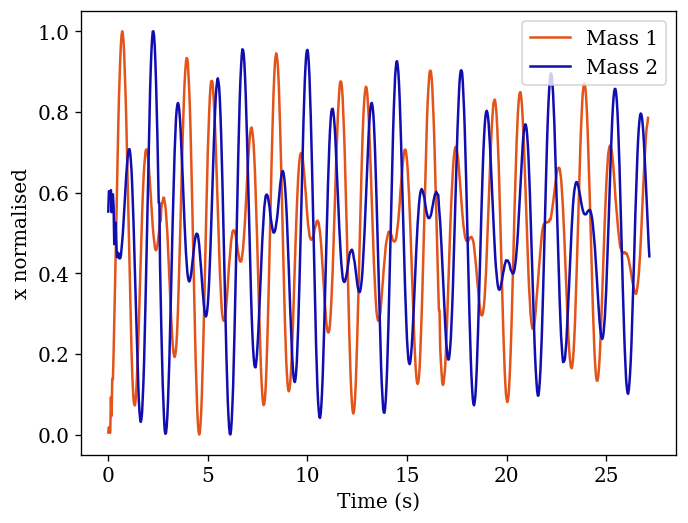

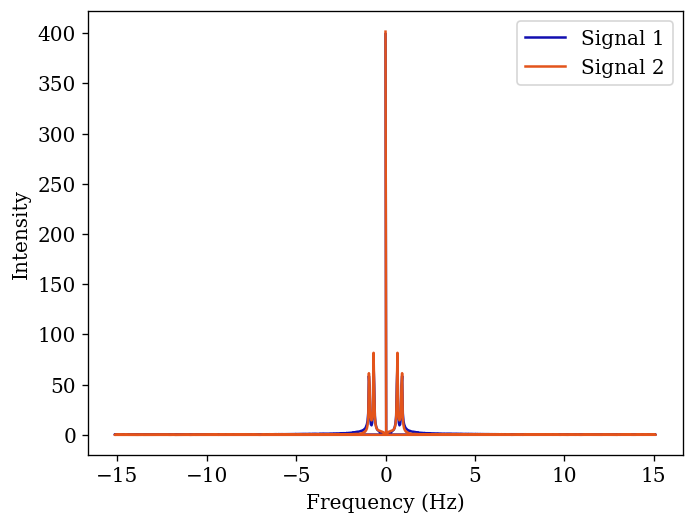

[ 18  25 789 796]
4
First peak is  [ 0.67009158  0.93068275 -0.93068275 -0.67009158]
Second peak is  [ 0.6684492   0.92840166 -0.92840166 -0.6684492 ]


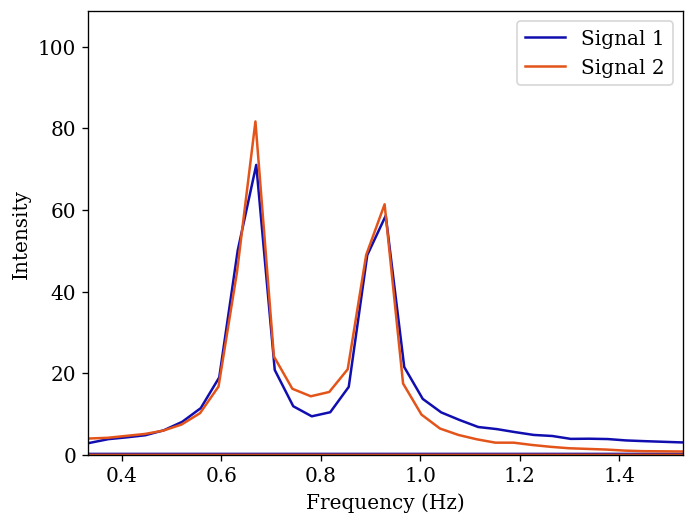

In [30]:
S2_randomA = np.loadtxt("../Coupled_Pendulum/S2_random_mA.txt", delimiter=',', skiprows=2)
S2_randomB = np.loadtxt("../Coupled_Pendulum/S2_random_mB.txt", delimiter=',', skiprows=2)

plotwaves(S2_randomA, S2_randomB,delta=[0.6,50])